**Matrice de corrélation**

In [2]:
from protocole_données import *
df = Base_de_donnees(['sea_level','sea_temperature','greenland_mass','antarctica_mass','chlorophylle','CO2','sea_salinity'])
print(df.head())

    year_month  sea_level  sea_temperature  greenland_mass  antarctica_mass  \
348 2011-01-01   9.262305         0.226447        -2309.49          -909.68   
349 2011-02-01   6.970359         0.215230        -2296.91          -945.82   
350 2011-03-01   5.213225         0.201122        -2284.49          -969.73   
351 2011-04-01   4.805761         0.183305        -2283.34          -998.69   
352 2011-05-01   5.637375         0.176820        -2302.29          -926.03   

     chlorophylle       CO2  sea_salinity  
348     -0.001784  4.437500      0.036705  
349     -0.006570  1.727500      0.040851  
350     -0.022812  4.200000      0.024237  
351     -0.009934  2.766667      0.018830  
352      0.002212  1.616667     -0.017675  


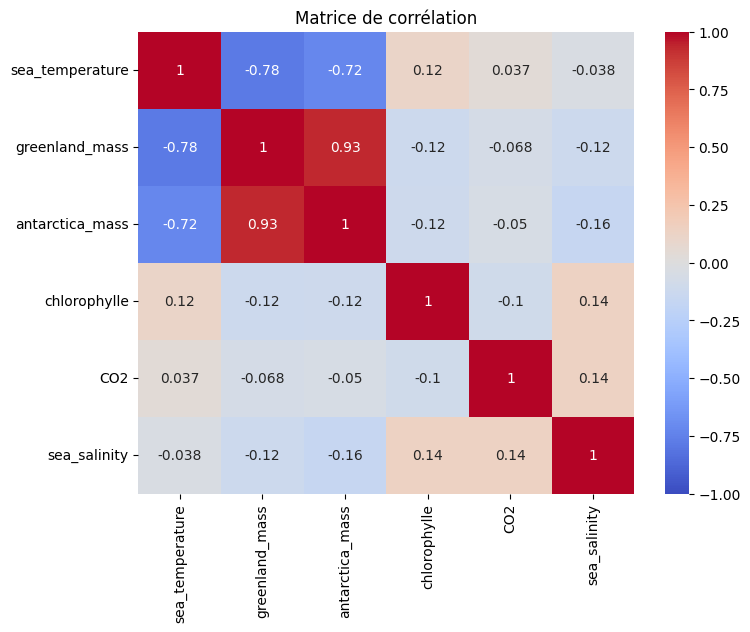

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose que df contient tes variables :
corr = df[['sea_temperature','greenland_mass','antarctica_mass','chlorophylle','CO2','sea_salinity']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

**Interaction entre les variables**

In [12]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

features = ['sea_temperature', 'greenland_mass', 'antarctica_mass', 'chlorophylle', 'CO2', 'sea_salinity']
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df[features])

X_scaled = pd.DataFrame(X_scaled_array, columns=features)

X_scaled['sea_level'] = df['sea_level']

formula = 'sea_level ~ sea_temperature + greenland_mass + antarctica_mass + CO2 + chlorophylle + sea_salinity \
           + sea_temperature:greenland_mass + CO2:sea_temperature + chlorophylle:sea_temperature'


model = smf.ols(formula=formula, data=X_scaled).fit()


print(model.summary())

ValueError: zero-size array to reduction operation maximum which has no identity

In [13]:
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

# Étape 1 : Définir les noms des colonnes à utiliser
features = ['sea_temperature', 'greenland_mass', 'antarctica_mass', 'chlorophylle', 'CO2', 'sea_salinity']

# Étape 2 : Vérifier que toutes les colonnes existent dans le DataFrame d'origine
missing_cols = [col for col in features if col not in df.columns]
if missing_cols:
    print(f"Colonnes manquantes dans df: {missing_cols}")
else:
    # Étape 3 : Standardiser les variables
    scaler = StandardScaler()
    X_scaled_array = scaler.fit_transform(df[features])
    X_scaled = pd.DataFrame(X_scaled_array, columns=features)

    # Étape 4 : Ajouter la variable cible
    X_scaled['sea_level'] = df['sea_level'].values

    # Étape 5 : Vérifie visuellement les noms de colonnes
    print("Colonnes disponibles :", X_scaled.columns.tolist())

    # Étape 6 : Écrire la formule avec les bons noms
    formula = 'sea_level ~ sea_temperature + greenland_mass + antarctica_mass + CO2 + chlorophylle + sea_salinity \
               + sea_temperature:greenland_mass + CO2:sea_temperature + chlorophylle:sea_temperature'

    # Étape 7 : Modélisation
    model = smf.ols(formula=formula, data=X_scaled).fit()

    # Étape 8 : Résumé
    print(model.summary())


Colonnes disponibles : ['sea_temperature', 'greenland_mass', 'antarctica_mass', 'chlorophylle', 'CO2', 'sea_salinity', 'sea_level']
                            OLS Regression Results                            
Dep. Variable:              sea_level   R-squared:                       0.394
Model:                            OLS   Adj. R-squared:                  0.354
Method:                 Least Squares   F-statistic:                     9.691
Date:                Fri, 02 May 2025   Prob (F-statistic):           2.57e-11
Time:                        12:49:30   Log-Likelihood:                -269.82
No. Observations:                 144   AIC:                             559.6
Df Residuals:                     134   BIC:                             589.3
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|    

In [14]:
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf

# Formule 1 : modèle simple (effets principaux uniquement)
formula_simple = 'sea_level ~ sea_temperature + greenland_mass + antarctica_mass + CO2 + chlorophylle + sea_salinity'

# Formule 2 : modèle avec interactions
formula_inter = 'sea_level ~ sea_temperature + greenland_mass + antarctica_mass + CO2 + chlorophylle + sea_salinity \
                 + sea_temperature:greenland_mass + CO2:sea_temperature + chlorophylle:sea_temperature'

# Ajustement des deux modèles
model_simple = smf.ols(formula=formula_simple, data=X_scaled).fit()
model_inter = smf.ols(formula=formula_inter, data=X_scaled).fit()

# Analyse de la variance
anova_results = anova_lm(model_simple, model_inter)
print(anova_results)

   df_resid         ssr  df_diff    ss_diff         F    Pr(>F)
0     137.0  417.738164      0.0        NaN       NaN       NaN
1     134.0  357.626657      3.0  60.111507  7.507775  0.000111


In [15]:
import statsmodels.api as sm

# ANOVA Type II sur le modèle avec interactions
anova_type2 = sm.stats.anova_lm(model_inter, typ=2)
print(anova_type2)

                                    sum_sq     df          F    PR(>F)
sea_temperature                   0.033189    1.0   0.012436  0.911374
greenland_mass                   13.858354    1.0   5.192620  0.024265
antarctica_mass                   0.009314    1.0   0.003490  0.952981
CO2                               0.379627    1.0   0.142243  0.706658
chlorophylle                      0.004600    1.0   0.001724  0.966946
sea_salinity                      5.490092    1.0   2.057096  0.153828
sea_temperature:greenland_mass    0.085115    1.0   0.031892  0.858535
CO2:sea_temperature               5.048469    1.0   1.891623  0.171314
chlorophylle:sea_temperature     52.102459    1.0  19.522397  0.000020
Residual                        357.626657  134.0        NaN       NaN


In [17]:
import statsmodels.api as sm

# ANOVA sur le modèle avec interactions
anova_table = sm.stats.anova_lm(model, typ=3)  # typ=2 ou typ=3 selon ton objectif
print(anova_table)

                                     sum_sq     df            F        PR(>F)
Intercept                       5640.522088    1.0  2113.460908  6.358751e-84
sea_temperature                    1.741924    1.0     0.652686  4.205859e-01
greenland_mass                    13.510459    1.0     5.062267  2.608254e-02
antarctica_mass                    0.009314    1.0     0.003490  9.529814e-01
CO2                                1.283312    1.0     0.480847  4.892391e-01
chlorophylle                       1.407140    1.0     0.527245  4.690339e-01
sea_salinity                       5.490092    1.0     2.057096  1.538282e-01
sea_temperature:greenland_mass     0.085115    1.0     0.031892  8.585351e-01
CO2:sea_temperature                5.048469    1.0     1.891623  1.713139e-01
chlorophylle:sea_temperature      52.102459    1.0    19.522397  2.033362e-05
Residual                         357.626657  134.0          NaN           NaN
